## Section 1: Environment Setup and Data Loading

This section prepares the analysis environment by installing and importing the required Python libraries used throughout the machine learning and fairness evaluation pipeline. The UCI Heart Disease dataset (fedesoriano, 2021) is then loaded into a pandas DataFrame for subsequent preprocessing, model development, and evaluation. The dataset file (`heart.csv`) must be uploaded to the Colab environment before execution, and the initial dataset dimensions are displayed to confirm successful loading.

In [1]:
# Install required libraries
# Version pinned: Section 8.1 uses ExponentiatedGradient._pmf_predict, a private
# Fairlearn API not covered by the library's stability guarantees.
!pip install "fairlearn>=0.12,<0.15" -q

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

# Load dataset
# heart.csv must be uploaded to the Colab session before running.
df = pd.read_csv('heart.csv')
print("Data loaded successfully:", df.shape)

Data loaded successfully: (918, 12)


## Section 2: Data Inspection

This section evaluates the initial structure and quality of the raw dataset before preprocessing. Dataset dimensions, feature data types, missing value patterns, and potential data quality issues are examined to identify any requirements for cleaning prior to model development.

Additional checks are performed on clinically relevant variables, including zero values in `Cholesterol` and `RestingBP`, as these values may represent invalid measurements requiring treatment during preprocessing. The distributions of key demographic variables, including sex and age, are also inspected as these attributes are later used for subgroup fairness evaluation.


In [2]:

# Basic structure check
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

# Flag implausible zero values
print("\nZero Cholesterol:", (df['Cholesterol'] == 0).sum())
print("Zero RestingBP:", (df['RestingBP'] == 0).sum())

# Sensitive attribute distributions
print("\nSex distribution:\n", df['Sex'].value_counts())
print("\nHeartDisease distribution:\n", df['HeartDisease'].value_counts())
print("\nAge range:", df['Age'].min(), "to", df['Age'].max())

# Preview first five rows
df.head()


Shape: (918, 12)

Data types:
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

Missing values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Zero Cholesterol: 172
Zero RestingBP: 1

Sex distribution:
 Sex
M    725
F    193
Name: count, dtype: int64

HeartDisease distribution:
 HeartDisease
1    508
0    410
Name: count, dtype: int64

Age range: 28 to 77


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## Section 3: Data Cleaning and Feature Engineering

This section performs initial data cleaning and creates additional variables required for the fairness analysis. Clinically implausible zero values identified during the data inspection stage are converted to missing values, allowing them to be appropriately handled during subsequent preprocessing.

An age grouping variable is created to enable subgroup evaluation across clinically relevant age categories: Under 45, 45–60, and Over 60. These categories support the assessment of whether model performance and fairness outcomes vary across different stages of cardiovascular risk, as cardiovascular disease risk increases with age and older populations experience higher disease prevalence (British Heart Foundation [BHF], 2021a).

In [3]:
# Cleaning and feature engineering

# Zero cholesterol is biologically implausible - mark as missing
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)

# Single zero RestingBP - mark as missing
df['RestingBP'] = df['RestingBP'].replace(0, np.nan)

# Bin Age into three clinically relevant groups for fairness analysis
df['AgeGroup'] = pd.cut(df['Age'],
                        bins=[0, 45, 60, 100],
                        labels=['Under 45', '45-60', 'Over 60'])

# Retain original labels for sensitive attributes before encoding
df['Sex_original'] = df['Sex']
df['AgeGroup_original'] = df['AgeGroup']

print("Missing Cholesterol:", df['Cholesterol'].isna().sum())
print("Missing RestingBP:", df['RestingBP'].isna().sum())
print("\nAge group distribution:\n", df['AgeGroup'].value_counts())

Missing Cholesterol: 172
Missing RestingBP: 1

Age group distribution:
 AgeGroup
45-60       501
Over 60     221
Under 45    196
Name: count, dtype: int64


## Section 4: Feature Encoding

Categorical variables are transformed into numerical representations to allow their use within the logistic regression model. Binary variables (`Sex` and `ExerciseAngina`) are label encoded, as they contain two categories and do not introduce meaningful ordinal relationships.

Nominal categorical variables (`ChestPainType`, `RestingECG`, and `ST_Slope`) are converted using one-hot encoding to avoid introducing artificial ordering between categories, which could incorrectly influence the model coefficients. Original demographic labels retained during earlier preprocessing are preserved separately to support subgroup comparisons during fairness evaluation.

In [4]:
# Encoding
# Binary features: label encode (no false ordering with two levels)
# Nominal features: one-hot encode - label encoding would impose a
# spurious ordinal relationship that logistic regression reads as magnitude

binary_cols = ['Sex', 'ExerciseAngina']
nominal_cols = ['ChestPainType', 'RestingECG', 'ST_Slope']

encoders = {}
for col in binary_cols:
    encoders[col] = LabelEncoder()
    df[col] = encoders[col].fit_transform(df[col])
    print(f"{col}: {dict(zip(encoders[col].classes_, encoders[col].transform(encoders[col].classes_)))}")

df = pd.get_dummies(df, columns=nominal_cols, drop_first=True, dtype=int)

print("\nEncoded shape:", df.shape)
print("Columns:", list(df.columns))

Sex: {'F': np.int64(0), 'M': np.int64(1)}
ExerciseAngina: {'N': np.int64(0), 'Y': np.int64(1)}

Encoded shape: (918, 19)
Columns: ['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'HeartDisease', 'AgeGroup', 'Sex_original', 'AgeGroup_original', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Flat', 'ST_Slope_Up']


## Section 5: Baseline Model Training and Evaluation

A logistic regression classifier is developed as the baseline model against which fairness interventions are later compared. Logistic regression was selected due to its interpretability, transparency of feature relationships, and common use within clinical machine learning research. These characteristics support the evaluation of procedural fairness principles, particularly ethicality and correctability, by enabling greater understanding and review of model decisions (Leventhal, 1980).

The dataset is divided into training and testing subsets using an 80/20 split with a fixed random seed (`random_state=42`) to support reproducibility. Stratification is performed using the combination of outcome class and sex to maintain representation of demographic groups within the test set, which is important for reliable subgroup fairness evaluation.

Missing values introduced during the cleaning stage are handled within a preprocessing pipeline. Median imputation values are learned only from the training data and then applied to the test data, preventing information leakage between evaluation and model development. Features are standardised before training the logistic regression classifier.

Sex and Age are retained as model inputs because removing demographic attributes does not necessarily prevent models from learning demographic-related patterns through correlated clinical variables. Simply excluding protected attributes (often referred to as fairness through unawareness) has been shown to be insufficient for ensuring fair algorithmic decision making (Dwork et al., 2012).

Baseline performance is evaluated using AUC-ROC, accuracy, precision, recall, and F1-score. Recall for the positive class (heart disease present) is prioritised as the primary clinical metric in this study, on the reasoning that false negatives represent missed diagnoses and may present greater patient safety risks than false positives in a screening context. This prioritisation involves a trade-off, as increasing recall may result in additional false positive cases requiring follow-up assessment. Meerwijk et al. (2024) argue that the relative consequences of false positive and false negative errors should be explicitly considered when evaluating the fairness and clinical utility of decision support algorithms, although their work addresses resource-limited clinical interventions rather than diagnostic screening specifically. The weighting applied here therefore reflects the clinical reasoning of this study rather than a directly transferable finding.

In [5]:
# split impute train
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import confusion_matrix


class SexGroupMedianImputer(BaseEstimator, TransformerMixin):
    """Impute missing values with the median within each sex group.

    Medians are learned from training data only (fit), then applied to
    unseen data (transform), so no test-set information leaks into
    preprocessing. Sex is expected as an encoded column in X.
    """
    def __init__(self, columns, sex_col='Sex'):
        self.columns = columns
        self.sex_col = sex_col

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.medians_ = {
            col: X.groupby(self.sex_col)[col].median().to_dict()
            for col in self.columns
        }
        self.global_medians_ = {col: X[col].median() for col in self.columns}
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for col in self.columns:
            fill = X[self.sex_col].map(self.medians_[col])
            fill = fill.fillna(self.global_medians_[col])
            X[col] = X[col].fillna(fill)
        return X


def group_metrics(y_true, y_pred, mask):
    """Accuracy, recall and n for a subgroup."""
    yt = np.asarray(y_true)[np.asarray(mask)]
    yp = np.asarray(y_pred)[np.asarray(mask)]
    pos = (yt == 1).sum()
    recall = ((yp == 1) & (yt == 1)).sum() / pos if pos else float('nan')
    return accuracy_score(yt, yp), recall, np.asarray(mask).sum()


X = df.drop(columns=['HeartDisease', 'AgeGroup', 'Sex_original', 'AgeGroup_original'])
y = df['HeartDisease']

sensitive_sex = df['Sex_original']
sensitive_age = df['AgeGroup_original']

# Stratify on outcome and sex jointly so the female test count is not left to chance
strata = df['HeartDisease'].astype(str) + "_" + df['Sex_original'].astype(str)

X_train, X_test, y_train, y_test, sex_train, sex_test, age_train, age_test = train_test_split(
    X, y, sensitive_sex, sensitive_age,
    test_size=0.2,
    random_state=42,
    stratify=strata
)

# Impute and scale inside a Pipeline so both are fitted on training data only,
# preventing test-set information from leaking into preprocessing
model = Pipeline([
    ('impute', SexGroupMedianImputer(columns=['Cholesterol', 'RestingBP'])),
    ('scale', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("BASELINE MODEL PERFORMANCE")
print(f"AUC-ROC          : {roc_auc_score(y_test, y_prob):.3f}")
print(f"Overall Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion matrix (rows=actual, cols=predicted):")
print(confusion_matrix(y_test, y_pred))
print(f"\nTest set composition: {(sex_test=='M').sum()} male, {(sex_test=='F').sum()} female")

print("\nImputation medians (learned on training data):")
for col, medians in model.named_steps['impute'].medians_.items():
    print(f"  {col}: {medians}")

BASELINE MODEL PERFORMANCE
AUC-ROC          : 0.957
Overall Accuracy : 0.891

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88        82
           1       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184

Confusion matrix (rows=actual, cols=predicted):
[[71 11]
 [ 9 93]]

Test set composition: 145 male, 39 female

Imputation medians (learned on training data):
  Cholesterol: {0: 248.0, 1: 237.0}
  RestingBP: {0: 130.0, 1: 130.0}


## Section 6: Leventhal Fairness Assessment — Baseline Model

This section evaluates the baseline logistic regression model against all six of Leventhal's (1980) procedural justice rules. Following the sociotechnical perspective proposed by Selbst et al. (2019), the criteria are divided into two categories:

**Technical criteria** — assessed computationally using quantitative thresholds:
- Accuracy (6.1)
- Bias Suppression (6.2)
- Representativeness (6.3)
- Consistency (6.4)

**Sociotechnical criteria** — assessed qualitatively using structured checklists, as these cannot be fully captured through pipeline metrics alone:
- Correctability (6.5)
- Ethicality (6.6)

A summary of all six assessments is presented in Section 6.7. The same assessment framework is repeated on the mitigated model in Section 8 to enable direct comparison.

### Section 6.1: Accuracy

Leventhal's accuracy rule requires that decisions are based on reliable information and processed with minimal error (Leventhal, 1980). This criterion is assessed using the model's AUC-ROC performance on the held-out test set, with a predefined threshold of 0.80 used as the minimum requirement for passing the accuracy criterion. Values above this threshold are commonly interpreted as demonstrating good ability to distinguish between two outcomes (Mandrekar, 2010).

AUC-ROC is selected as the primary evaluation measure because it assesses the model's ability to distinguish between patients with and without heart disease across different classification thresholds. Compared with accuracy alone, AUC-ROC provides a more informative measure when considering potential differences in class distribution. Overall accuracy, precision, recall, and F1-score are also reported to provide additional context regarding model performance.

While strong overall predictive performance is necessary, accuracy alone does not establish fairness. Therefore, subsequent criteria evaluate potential disparities in model performance, representation, and decision-making processes across patient groups.

In [6]:
# Compute overall accuracy and AUC-ROC
overall_accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("LEVENTHAL RULE 1: ACCURACY")
print(f"Overall Accuracy : {overall_accuracy:.3f}")
print(f"AUC-ROC          : {auc:.3f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred))

threshold = 0.80
print()
if auc >= threshold:
    print(f"PASS — AUC-ROC ({auc:.3f}) meets the 0.80 threshold.")
    print(f"       Overall accuracy ({overall_accuracy:.1%}) reported as context.")
else:
    print(f"FAIL — AUC-ROC ({auc:.3f}) falls below the 0.80 threshold.")

LEVENTHAL RULE 1: ACCURACY
Overall Accuracy : 0.891
AUC-ROC          : 0.957

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88        82
           1       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184


PASS — AUC-ROC (0.957) meets the 0.80 threshold.
       Overall accuracy (89.1%) reported as context.


### Section 6.2: Bias Suppression

Leventhal's bias suppression rule requires that decision processes minimise unjustified influence from characteristics unrelated to the intended outcome (Leventhal, 1980). In the context of healthcare AI, this criterion is evaluated by examining whether model performance differs substantially across demographic groups.

Performance is disaggregated by sex and age group using subgroup accuracy and recall. Formal fairness evaluation is conducted across sex groups using Fairlearn's demographic parity difference and equalised odds difference metrics. Demographic parity difference measures differences in positive prediction rates between groups, while equalised odds difference measures differences in true positive and false positive rates.

An operational disparity threshold of ±0.10 is applied, where values closer to zero indicate smaller group-level differences. However, fairness metrics are interpreted alongside clinical performance measures, as reducing statistical disparities alone does not guarantee equitable clinical outcomes.

In [7]:
print("LEVENTHAL RULE 2: BIAS SUPPRESSION")

# Group level performance by sex
print("\nPerformance by Sex:")
for group in ['M', 'F']:
    acc, recall, n = group_metrics(y_test, y_pred, sex_test == group)
    print(f"  {group} | Accuracy: {acc:.3f} | Recall: {recall:.3f} | n={n}")

# Group level performance by age group
print("\nPerformance by Age Group:")
for group in ['Under 45', '45-60', 'Over 60']:
    acc, recall, n = group_metrics(y_test, y_pred, age_test == group)
    print(f"  {group} | Accuracy: {acc:.3f} | Recall: {recall:.3f} | n={n}")

# Formal fairness metrics
print("\nFormal Fairness Metrics (Sex):")
dp_diff = demographic_parity_difference(y_test, y_pred, sensitive_features=sex_test)
eo_diff = equalized_odds_difference(y_test, y_pred, sensitive_features=sex_test)
print(f"  Demographic Parity Difference : {dp_diff:.3f}")
print(f"  Equalised Odds Difference     : {eo_diff:.3f}")

# Pass/fail against ±0.10 threshold
threshold = 0.10
print()
if abs(dp_diff) <= threshold and abs(eo_diff) <= threshold:
    print("PASS — Bias suppression within acceptable threshold (±0.10).")
else:
    print("FAIL — Bias suppression exceeds acceptable threshold (±0.10).")
    print(f"  Demographic Parity Difference: {dp_diff:.3f}")
    print(f"  Equalised Odds Difference: {eo_diff:.3f}")

LEVENTHAL RULE 2: BIAS SUPPRESSION

Performance by Sex:
  M | Accuracy: 0.890 | Recall: 0.935 | n=145
  F | Accuracy: 0.897 | Recall: 0.700 | n=39

Performance by Age Group:
  Under 45 | Accuracy: 0.946 | Recall: 0.857 | n=37
  45-60 | Accuracy: 0.873 | Recall: 0.906 | n=102
  Over 60 | Accuracy: 0.889 | Recall: 0.943 | n=45

Formal Fairness Metrics (Sex):
  Demographic Parity Difference : 0.457
  Equalised Odds Difference     : 0.235

FAIL — Bias suppression exceeds acceptable threshold (±0.10).
  Demographic Parity Difference: 0.457
  Equalised Odds Difference: 0.235


### Section 6.3: Representativeness

Leventhal's representativeness rule requires that decision-making processes consider information from sufficiently representative groups to reduce the risk that outcomes are based on incomplete or skewed evidence (Leventhal, 1980). In this study, representativeness is assessed by comparing the demographic composition of the dataset against available real-world cardiovascular disease reference data.

For sex representation, the proportion of female patients within the dataset is compared with the reported proportion of female coronary heart disease inpatients from BHF (2021a) data. A representation ratio is calculated by dividing the dataset female proportion by the reference female proportion. A threshold of 0.80 is applied, adapted from the four-fifths rule used in employment fairness contexts (EEOC, 1978). The application of this threshold to healthcare dataset composition is treated as an operational assumption of this study rather than an established clinical standard.

Age-group representation is assessed through a directional comparison between dataset distributions and reported coronary heart disease prevalence patterns across age groups (BHF, 2021b). As these reference values represent prevalence rates rather than proportions of diagnosed cases, they are used to identify potential differences in age representation rather than as a formal pass/fail metric.

In [8]:
print("LEVENTHAL RULE 3: REPRESENTATIVENESS")
print()

# Dataset demographic breakdown
total = len(df)
female_count = (df['Sex_original'] == 'F').sum()
male_count = (df['Sex_original'] == 'M').sum()
dataset_female_pct = female_count / total
dataset_male_pct = male_count / total

print("Dataset Demographics:")
print(f"  Male   : {male_count} ({dataset_male_pct:.1%})")
print(f"  Female : {female_count} ({dataset_female_pct:.1%})")

# Age group breakdown
print()
print("Age Group Distribution:")
for group in ['Under 45', '45-60', 'Over 60']:
    count = (df['AgeGroup_original'] == group).sum()
    pct = count / total
    print(f"  {group} : {count} ({pct:.1%})")

# Sex representativeness — BHF (2021a) reference: 33% female CHD inpatients England 2019/20
reference_female_pct = 0.33
representation_ratio_sex = dataset_female_pct / reference_female_pct

print()
print("Representativeness Assessment (Sex):")
print(f"  Dataset female prevalence   : {dataset_female_pct:.1%}")
print(f"  Reference female prevalence : {reference_female_pct:.1%} (BHF, 2021a)")
print(f"  Representation ratio        : {representation_ratio_sex:.2f}")

threshold = 0.80
print()
if representation_ratio_sex >= threshold:
    print(f"PASS — Female representation ratio ({representation_ratio_sex:.2f}) meets threshold (0.80).")
else:
    print(f"FAIL — Female representation ratio ({representation_ratio_sex:.2f}) falls below threshold (0.80).")
    print("  Female patients are underrepresented relative to real-world CHD prevalence.")

# Age representativeness — directional comparison only
# BHF (2021b) figures reflect prevalence rates within age groups not proportions of total cases
age_reference = {
    'Under 45': 0.009,
    '45-60': 0.075,
    'Over 60': 0.270
}

print()
print("Representativeness Assessment (Age Groups — Directional):")
print("Reference: CHD prevalence rates within age groups, England 2017 (BHF, 2021b)")
print()
for group in ['Under 45', '45-60', 'Over 60']:
    count = (df['AgeGroup_original'] == group).sum()
    dataset_pct = count / total
    ref_pct = age_reference[group]
    print(f"  {group} | Dataset: {dataset_pct:.1%} | Reference prevalence: {ref_pct:.1%}")

# Calculate under-60 percentage dynamically
under_45_pct = (df['AgeGroup_original'] == 'Under 45').sum() / total
pct_45_60 = (df['AgeGroup_original'] == '45-60').sum() / total
under_60_pct = under_45_pct + pct_45_60

print()
print("Interpretation:")
print("  CHD prevalence rises sharply with age (0.9% under 45 vs 27.0% over 60).")
print(f"  Yet {under_60_pct:.1%} of dataset patients are under 60, suggesting younger patients")
print("  are overrepresented relative to real-world CHD burden.")
print("  FAIL — dataset age distribution does not reflect real-world CHD prevalence pattern.")

LEVENTHAL RULE 3: REPRESENTATIVENESS

Dataset Demographics:
  Male   : 725 (79.0%)
  Female : 193 (21.0%)

Age Group Distribution:
  Under 45 : 196 (21.4%)
  45-60 : 501 (54.6%)
  Over 60 : 221 (24.1%)

Representativeness Assessment (Sex):
  Dataset female prevalence   : 21.0%
  Reference female prevalence : 33.0% (BHF, 2021a)
  Representation ratio        : 0.64

FAIL — Female representation ratio (0.64) falls below threshold (0.80).
  Female patients are underrepresented relative to real-world CHD prevalence.

Representativeness Assessment (Age Groups — Directional):
Reference: CHD prevalence rates within age groups, England 2017 (BHF, 2021b)

  Under 45 | Dataset: 21.4% | Reference prevalence: 0.9%
  45-60 | Dataset: 54.6% | Reference prevalence: 7.5%
  Over 60 | Dataset: 24.1% | Reference prevalence: 27.0%

Interpretation:
  CHD prevalence rises sharply with age (0.9% under 45 vs 27.0% over 60).
  Yet 75.9% of dataset patients are under 60, suggesting younger patients
  are overrep

### Section 6.3 (cont.): Representativeness Visualisation

Figure 1 provides a visual comparison between the demographic composition of the dataset and external cardiovascular disease reference data. The sex distribution comparison contrasts the dataset composition with female and male coronary heart disease inpatient proportions reported by BHF (2021a).

The age distribution comparison contrasts dataset age groups with reported coronary heart disease prevalence patterns across age categories from BHF (2021b). These age comparisons are presented directionally, as the reference values represent prevalence rates within age groups rather than the expected proportion of cases within a clinical dataset.

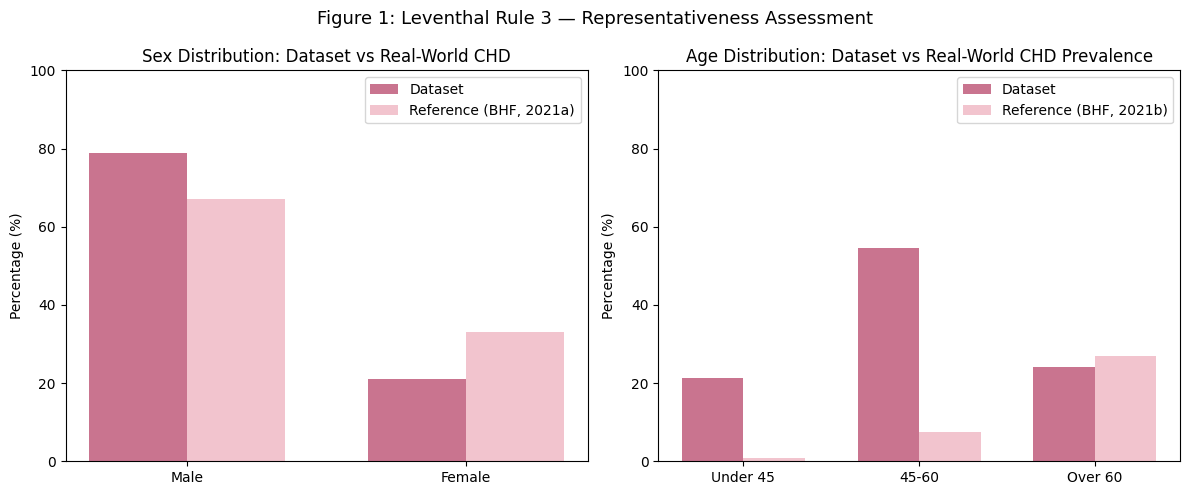

Figure 1 saved as representativeness_chart.png


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sex_labels = ['Male', 'Female']
dataset_sex = [dataset_male_pct * 100, dataset_female_pct * 100]
reference_sex = [67, 33]
x = np.arange(len(sex_labels))
width = 0.35

ax1.bar(x - width/2, dataset_sex, width, label='Dataset', color='#c9748f')
ax1.bar(x + width/2, reference_sex, width, label='Reference (BHF, 2021a)', color='#f2c4ce')
ax1.set_title('Sex Distribution: Dataset vs Real-World CHD')
ax1.set_ylabel('Percentage (%)')
ax1.set_xticks(x)
ax1.set_xticklabels(sex_labels)
ax1.legend()
ax1.set_ylim(0, 100)

age_labels = ['Under 45', '45-60', 'Over 60']
x2 = np.arange(len(age_labels))
dataset_age = [(df['AgeGroup_original'] == g).sum() / total * 100 for g in age_labels]
reference_age = [age_reference[g] * 100 for g in age_labels]

ax2.bar(x2 - width/2, dataset_age, width, label='Dataset', color='#c9748f')
ax2.bar(x2 + width/2, reference_age, width, label='Reference (BHF, 2021b)', color='#f2c4ce')
ax2.set_title('Age Distribution: Dataset vs Real-World CHD Prevalence')
ax2.set_ylabel('Percentage (%)')
ax2.set_xticks(x2)
ax2.set_xticklabels(age_labels)
ax2.legend()
ax2.set_ylim(0, 100)

plt.suptitle('Figure 1: Leventhal Rule 3 — Representativeness Assessment', fontsize=13)
plt.tight_layout()
plt.savefig('representativeness_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 1 saved as representativeness_chart.png")

### Section 6.4: Consistency

Leventhal's consistency rule requires that decision processes apply stable and predictable logic across comparable cases (Leventhal, 1980). In this study, consistency is operationalised through a prediction stability assessment that measures how sensitive model outputs are to small, clinically realistic variations in patient measurements.

Gaussian noise was scaled according to the clinical measurement units of each continuous feature rather than applying a uniform perturbation across all variables. Because Oldpeak represents ST-segment depression measured in millimetres, a standard deviation of ±0.1 mm was selected as an operational perturbation magnitude to avoid disproportionately large changes relative to its measurement scale. This value was defined by the researcher for the purposes of robustness testing rather than being derived from an established clinical standard.

Binary variables, including FastingBS, are excluded from perturbation because adding continuous noise to a two-level indicator would not represent meaningful clinical variation. The proportion of predictions that change after perturbation is reported as the instability rate.

Because the perturbation is stochastic, the instability rate obtained from a single random draw is sensitive to the seed used. The test is therefore repeated across twenty seeds and the mean and range are reported alongside the single-seed result. A margin diagnostic is also included, recording how many test cases fall close to the 0.50 decision boundary, as the number of near-boundary cases determines how sensitive the model can be to small input changes.

A maximum instability threshold of 5% is applied as a conservative operational benchmark defined for this study, as no established clinical standard currently exists for prediction stability testing of this type. A fixed random seed is used to support reproducibility.

The high stability reflects the separability of the classification problem rather than any property of the perturbation itself. Only two of 184 test cases fall within 0.05 of the 0.50 decision boundary, with a median margin of 0.417, so few predictions are close enough to the boundary for small input variations to change them.

In [10]:
print("LEVENTHAL RULE 4: CONSISTENCY")
print()

np.random.seed(42)

# Add clinically realistic measurement noise to continuous features only.
# FastingBS is excluded: it is a binary indicator (0/1), so Gaussian noise
# has no measurement interpretation.
# Noise is scaled per feature rather than applied uniformly, because a
# fixed ±1 unit is trivial for Cholesterol (mg/dl, range ~85-600) but
# very large for Oldpeak (ST depression in mm, range ~0-6.2).
noise_scales = {
    'Age':         1.0,   # ±1 year
    'RestingBP':   1.0,   # ±1 mmHg
    'Cholesterol': 1.0,   # ±1 mg/dl
    'MaxHR':       1.0,   # ±1 bpm
    'Oldpeak':     0.1,   # ±0.1 mm ST depression
}
continuous_features = list(noise_scales)

X_test_noisy = X_test.copy()
for col, scale in noise_scales.items():
    if col in X_test_noisy.columns:
        noise = np.random.normal(0, scale, X_test_noisy[col].shape)
        X_test_noisy[col] = X_test_noisy[col] + noise

# Compare predictions on original vs noisy test set
y_pred_original = model.predict(X_test)
y_pred_noisy = model.predict(X_test_noisy)

changed_predictions = (y_pred_original != y_pred_noisy).sum()
instability_rate = changed_predictions / len(y_pred_original)

print(f"Total test cases        : {len(y_pred_original)}")
print(f"Changed predictions     : {changed_predictions}")
print(f"Instability rate        : {instability_rate:.1%}")

# Pass/fail against 5% threshold
threshold = 0.05
print()
if instability_rate <= threshold:
    print(f"PASS — Instability rate ({instability_rate:.1%}) within acceptable threshold (5%).")
else:
    print(f"FAIL — Instability rate ({instability_rate:.1%}) exceeds acceptable threshold (5%).")

# Group level breakdown
print()
print("Consistency by Sex:")
for group in ['M', 'F']:
    mask = np.asarray(sex_test == group)
    changed = (y_pred_original[mask] != y_pred_noisy[mask]).sum()
    rate = changed / mask.sum()
    print(f"  {group} | Changed: {changed} / {mask.sum()} | Instability rate: {rate:.1%}")

print()
print("Consistency by Age Group:")
for group in ['Under 45', '45-60', 'Over 60']:
    mask = np.asarray(age_test == group)
    changed = (y_pred_original[mask] != y_pred_noisy[mask]).sum()
    rate = changed / mask.sum()
    print(f"  {group} | Changed: {changed} / {mask.sum()} | Instability rate: {rate:.1%}")

#multi seed stability check
# A single perturbation draw depends on the random seed. Because very few test
# cases sit close to the decision boundary, one draw can return 0% while another
# returns a small non-zero rate. The test is therefore repeated across multiple
# seeds and the distribution of instability rates is reported.

print()
print("Multi-seed stability check (20 seeds):")

n_seeds = 20
seed_rates = []

for seed in range(n_seeds):
    rng = np.random.default_rng(seed)
    X_seed = X_test.copy()
    for col, scale in noise_scales.items():
        if col in X_seed.columns:
            X_seed[col] = X_seed[col] + rng.normal(0, scale, X_seed[col].shape)
    y_seed = model.predict(X_seed)
    seed_rates.append((y_pred_original != y_seed).mean())

seed_rates = np.array(seed_rates)

print(f"  Seeds tested          : {n_seeds}")
print(f"  Mean instability rate : {seed_rates.mean():.2%}")
print(f"  Range                 : {seed_rates.min():.2%} to {seed_rates.max():.2%}")
print(f"  Seeds with 0 changes  : {(seed_rates == 0).sum()} / {n_seeds}")

print()
if seed_rates.max() <= threshold:
    print(f"PASS — instability remained within the 5% threshold across all {n_seeds} seeds.")
else:
    print(f"FAIL — instability exceeded the 5% threshold in at least one seed.")

# Margin diagnostic: explains why instability is so low
margins = np.abs(model.predict_proba(X_test)[:, 1] - 0.5)
print()
print("Decision boundary margins (baseline model):")
print(f"  Test cases within 0.05 of the 0.50 boundary : {(margins < 0.05).sum()} / {len(margins)}")
print(f"  Median margin                                : {np.median(margins):.3f}")

LEVENTHAL RULE 4: CONSISTENCY

Total test cases        : 184
Changed predictions     : 0
Instability rate        : 0.0%

PASS — Instability rate (0.0%) within acceptable threshold (5%).

Consistency by Sex:
  M | Changed: 0 / 145 | Instability rate: 0.0%
  F | Changed: 0 / 39 | Instability rate: 0.0%

Consistency by Age Group:
  Under 45 | Changed: 0 / 37 | Instability rate: 0.0%
  45-60 | Changed: 0 / 102 | Instability rate: 0.0%
  Over 60 | Changed: 0 / 45 | Instability rate: 0.0%

Multi-seed stability check (20 seeds):
  Seeds tested          : 20
  Mean instability rate : 0.03%
  Range                 : 0.00% to 0.54%
  Seeds with 0 changes  : 19 / 20

PASS — instability remained within the 5% threshold across all 20 seeds.

Decision boundary margins (baseline model):
  Test cases within 0.05 of the 0.50 boundary : 2 / 184
  Median margin                                : 0.417


### Section 6.5: Correctability

Leventhal's correctability rule requires that decision-making processes include mechanisms through which potentially inappropriate decisions can be reviewed, challenged, and corrected (Leventhal, 1980). This criterion cannot be evaluated solely through model performance metrics, as it depends on wider system design, governance processes, and human oversight mechanisms.

Correctability is therefore assessed qualitatively using a structured checklist developed for this study. The checklist evaluates transparency of model outputs, availability of confidence information, clinician and patient review mechanisms, auditability, model governance, and communication of uncertainty. The assessment approach is informed by existing AI governance frameworks, including the Assessment List for Trustworthy Artificial Intelligence (ALTAI) developed by the European Commission's High-Level Expert Group on Artificial Intelligence (EU HLEG, 2020), together with guidance on explaining AI-assisted decision-making published by the Information Commissioner's Office and the Alan Turing Institute (ICO and Alan Turing Institute, 2020).

As no validated instrument currently exists for evaluating Leventhal's procedural justice rules within healthcare machine learning systems, the checklist represents an operationalisation of these principles for this research context. A threshold of 80% of criteria met is applied as the passing requirement.

In [11]:
# Checklist developed for this study. No validated instrument exists for assessing
# Leventhal's rules in healthcare ML. The approach of operationalising governance
# principles as structured assessment questions follows ALTAI (EU HLEG, 2020);
# individual items are informed by ICO/Alan Turing Institute guidance on explaining
# AI decisions (2020), UK GDPR provisions on automated decision-making, and
# institutional research ethics requirements.

print("LEVENTHAL RULE 5: CORRECTABILITY")
print()

correctability_checklist = {
    "Prediction outputs are visible and interpretable"   : True,
    "Confidence scores are provided with predictions"    : True,
    "Clinician override mechanism exists"                : False,
    "Patient challenge mechanism exists"                 : False,
    "Audit trail of predictions is maintained"           : False,
    "Model version history is recorded"                  : False,
    "Dashboard communicates uncertainty to stakeholders" : True,
}

print("Correctability Checklist:")
print()
for criterion, status in correctability_checklist.items():
    result = "PASS" if status else "FAIL"
    print(f"  [{result}] {criterion}")

passed = sum(correctability_checklist.values())
total_checks = len(correctability_checklist)

print()
print(f"Criteria met: {passed} / {total_checks}")
print()
if passed / total_checks >= 0.8:
    print("PASS — Correctability criteria sufficiently met.")
else:
    print("FAIL — Correctability criteria not sufficiently met.")
    print("  The pipeline lacks clinician override and audit trail mechanisms.")
    print("  The dashboard partially addresses this through transparent")
    print("  communication of predictions and uncertainty to stakeholders.")
    print("  Full correctability requires institutional design beyond this project.")

LEVENTHAL RULE 5: CORRECTABILITY

Correctability Checklist:

  [PASS] Prediction outputs are visible and interpretable
  [PASS] Confidence scores are provided with predictions
  [FAIL] Clinician override mechanism exists
  [FAIL] Patient challenge mechanism exists
  [FAIL] Audit trail of predictions is maintained
  [FAIL] Model version history is recorded
  [PASS] Dashboard communicates uncertainty to stakeholders

Criteria met: 3 / 7

FAIL — Correctability criteria not sufficiently met.
  The pipeline lacks clinician override and audit trail mechanisms.
  The dashboard partially addresses this through transparent
  communication of predictions and uncertainty to stakeholders.
  Full correctability requires institutional design beyond this project.


### Section 6.6: Ethicality

Leventhal's ethicality rule requires that decision-making procedures align with accepted ethical standards, respect individual rights, and minimise the potential for unjust harm (Leventhal, 1980). Similar to correctability, ethicality cannot be fully assessed through computational metrics alone and is therefore evaluated using a structured qualitative checklist.

The checklist developed for this study evaluates ethical considerations across dataset use, research governance, privacy protection, transparency, and potential patient impact. Criteria include institutional ethics approval, anonymisation, data protection considerations, transparency of findings, and responsible use of healthcare data. The assessment approach follows established AI governance principles, including the Assessment List for Trustworthy Artificial Intelligence (ALTAI) (EU HLEG, 2020) and guidance on accountability, transparency, and explainability in AI-assisted decision-making published by the Information Commissioner's Office and the Alan Turing Institute (ICO and Alan Turing Institute, 2020).

One identified limitation concerns informed consent for machine learning research use. The UCI Heart Disease dataset originates from earlier clinical studies, and explicit consent for secondary AI research use could not be verified from the available dataset documentation. This represents a limitation associated with the historical use of clinical datasets and cannot be resolved retrospectively within this project. However, the limitation is acknowledged as part of responsible AI evaluation.

A threshold of 80% of criteria met is applied as the passing requirement.

In [12]:
# Checklist developed for this study. No validated instrument exists for assessing
# Leventhal's rules in healthcare ML. The approach of operationalising governance
# principles as structured assessment questions follows ALTAI (EU HLEG, 2020);
# individual items are informed by ICO/Alan Turing Institute guidance on explaining
# AI decisions (2020), UK GDPR provisions on automated decision-making, and
# institutional research ethics requirements.

print("LEVENTHAL RULE 6: ETHICALITY")
print()

ethicality_checklist = {
    "Ethics approval granted by Newcastle University"      : True,
    "Dataset is fully anonymised — no patient identifiers" : True,
    "No personal data collected or processed"              : True,
    "GDPR compliance — survey is anonymous"                : True,
    "Dataset used within its intended research purpose"    : True,
    "Patients gave informed consent for ML research use"   : False,
    "System designed to avoid unjust harm to patients"     : True,
    "Findings communicated transparently via dashboard"    : True,
}

print("Ethicality Checklist:")
print()
for criterion, status in ethicality_checklist.items():
    result = "PASS" if status else "FAIL"
    print(f"  [{result}] {criterion}")

passed = sum(ethicality_checklist.values())
total_checks = len(ethicality_checklist)

print()
print(f"Criteria met: {passed} / {total_checks}")
print()
if passed / total_checks >= 0.8:
    print("PASS — Ethicality criteria sufficiently met.")
    print("  Note: Informed consent for ML research use is marked as a known")
    print("  limitation. The dataset predates modern AI ethics frameworks and")
    print("  this cannot be resolved retroactively within this project.")
else:
    print("FAIL — Ethicality criteria not sufficiently met.")

LEVENTHAL RULE 6: ETHICALITY

Ethicality Checklist:

  [PASS] Ethics approval granted by Newcastle University
  [PASS] Dataset is fully anonymised — no patient identifiers
  [PASS] No personal data collected or processed
  [PASS] GDPR compliance — survey is anonymous
  [PASS] Dataset used within its intended research purpose
  [FAIL] Patients gave informed consent for ML research use
  [PASS] System designed to avoid unjust harm to patients
  [PASS] Findings communicated transparently via dashboard

Criteria met: 7 / 8

PASS — Ethicality criteria sufficiently met.
  Note: Informed consent for ML research use is marked as a known
  limitation. The dataset predates modern AI ethics frameworks and
  this cannot be resolved retroactively within this project.


### Section 6.7: Baseline Assessment Summary

This section summarises the results of the six Leventhal procedural fairness assessments applied to the baseline logistic regression model. The assessment identified both strengths and limitations within the initial pipeline, with three criteria meeting the defined thresholds and three criteria requiring further consideration.

The baseline model satisfies the accuracy, consistency, and ethicality criteria. However, bias suppression, representativeness, and correctability remain areas of concern. These findings demonstrate that strong predictive performance alone does not guarantee procedural fairness, as demographic disparities, dataset composition limitations, and governance mechanisms must also be considered.

Section 7 focuses on mitigating the identified bias suppression issue through a fairness-aware modelling approach. The impact of this intervention is reassessed in Section 8, including changes to model performance and consistency outcomes. The remaining limitations are addressed through recommendations and discussion: representativeness is a technical criterion but requires improvements to dataset composition rather than algorithmic adjustment, while correctability requires institutional governance mechanisms beyond the scope of this pipeline.

In [13]:
print("BASELINE LEVENTHAL ASSESSMENT SUMMARY")
print()

# Results are derived from the computed metrics above rather than hardcoded
baseline_results = {
    "Accuracy"          : "PASS" if auc >= 0.80 else "FAIL",
    "Bias Suppression"  : "PASS" if (abs(dp_diff) <= 0.10 and abs(eo_diff) <= 0.10) else "FAIL",
    "Representativeness": "PASS" if representation_ratio_sex >= 0.80 else "FAIL",
    "Consistency"       : "PASS" if instability_rate <= 0.05 else "FAIL",
    "Correctability"    : "PASS" if (sum(correctability_checklist.values())
                                     / len(correctability_checklist)) >= 0.80 else "FAIL",
    "Ethicality"        : "PASS" if (sum(ethicality_checklist.values())
                                     / len(ethicality_checklist)) >= 0.80 else "FAIL",
}

assessment_type = {
    "Accuracy"          : "Technical",
    "Bias Suppression"  : "Technical",
    "Representativeness": "Technical",
    "Consistency"       : "Technical",
    "Correctability"    : "Sociotechnical",
    "Ethicality"        : "Sociotechnical",
}

print(f"{'Rule':<20} {'Result':<10} {'Assessment Type':<15}")
print("-" * 48)
for rule, result in baseline_results.items():
    print(f"{rule:<20} {result:<10} {assessment_type[rule]:<15}")

passes = sum(1 for r in baseline_results.values() if r == "PASS")
fails = sum(1 for r in baseline_results.values() if r == "FAIL")

print()
print(f"Total PASS : {passes} / 6")
print(f"Total FAIL : {fails} / 6")
print()
print("Bias suppression mitigation is applied in Section 7.")
print("Remaining failures are addressed as recommendations in the dissertation.")


BASELINE LEVENTHAL ASSESSMENT SUMMARY

Rule                 Result     Assessment Type
------------------------------------------------
Accuracy             PASS       Technical      
Bias Suppression     FAIL       Technical      
Representativeness   FAIL       Technical      
Consistency          PASS       Technical      
Correctability       FAIL       Sociotechnical 
Ethicality           PASS       Sociotechnical 

Total PASS : 3 / 6
Total FAIL : 3 / 6

Bias suppression mitigation is applied in Section 7.
Remaining failures are addressed as recommendations in the dissertation.


## Section 7: Fairness Mitigation

The baseline assessment identified bias suppression as a key technical limitation, with demographic disparities observed in model performance across sex groups. This criterion is selected for mitigation because it can be directly addressed through changes to the model training process. Other identified limitations, including representativeness and correctability, involve broader dataset and governance considerations that cannot be fully resolved through algorithmic adjustment alone.

Fairlearn's ExponentiatedGradient algorithm is applied using an EqualizedOdds constraint to reduce disparities in false positive and true positive rates across sex groups. The method iteratively adjusts the weighting of training examples to identify a model that balances predictive performance with fairness objectives.

A constraint tolerance of `eps=0.01` is applied, allowing the optimisation process to seek improved fairness while maintaining acceptable predictive performance. The same preprocessing pipeline and logistic regression estimator used in the baseline model are retained to ensure a consistent comparison between the baseline and mitigated approaches. Sex is selected as the sensitive feature because it demonstrated the largest disparity during the baseline fairness assessment.

In [14]:
print("SECTION 7: FAIRNESS MITIGATION")
print()

# Apply ExponentiatedGradient with EqualizedOdds constraint.
# The base estimator is the same Pipeline used for the baseline model, so
# imputation and scaling are identical and the comparison is like-for-like.
# eps=0.01 sets constraint tolerance, allowing the optimiser to balance
# fairness against predictive performance.
constraint = EqualizedOdds()

mitigated_model = ExponentiatedGradient(
    Pipeline([
        ('impute', SexGroupMedianImputer(columns=['Cholesterol', 'RestingBP'])),
        ('scale', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    constraints=constraint,
    eps=0.01,
    sample_weight_name='clf__sample_weight'
)
mitigated_model.fit(X_train, y_train, sensitive_features=sex_train)
y_pred_mitigated = mitigated_model.predict(X_test)


# Overall performance
print(f"Overall Accuracy : {accuracy_score(y_test, y_pred_mitigated):.3f}")
print()

print("Performance by Sex:")
for group in ['M', 'F']:
    acc, rec, n = group_metrics(y_test, y_pred_mitigated, sex_test == group)
    print(f"  {group} | Accuracy: {acc:.3f} | Recall: {rec:.3f} | n={n}")

print()

print("Performance by Age Group:")
for group in ['Under 45', '45-60', 'Over 60']:
    acc, rec, n = group_metrics(y_test, y_pred_mitigated, age_test == group)
    print(f"  {group} | Accuracy: {acc:.3f} | Recall: {rec:.3f} | n={n}")
print()

# Formal fairness metrics — baseline vs mitigated comparison
print("Fairness Metrics: Baseline vs Mitigated")
print()
dp_diff_mitigated = demographic_parity_difference(y_test, y_pred_mitigated, sensitive_features=sex_test)
eo_diff_mitigated = equalized_odds_difference(y_test, y_pred_mitigated, sensitive_features=sex_test)
print(f"  Demographic Parity Difference : Baseline {dp_diff:.3f} → Mitigated {dp_diff_mitigated:.3f}")
print(f"  Equalised Odds Difference     : Baseline {eo_diff:.3f} → Mitigated {eo_diff_mitigated:.3f}")

print()
threshold = 0.10
if abs(dp_diff_mitigated) <= threshold and abs(eo_diff_mitigated) <= threshold:
    print("PASS — Bias suppression within acceptable threshold (±0.10) after mitigation.")
else:
    print("FAIL — Bias suppression still exceeds acceptable threshold (±0.10) after mitigation.")
    print(f"  Demographic Parity Difference: {dp_diff_mitigated:.3f}")
    print(f"  Equalised Odds Difference: {eo_diff_mitigated:.3f}")

SECTION 7: FAIRNESS MITIGATION

Overall Accuracy : 0.897

Performance by Sex:
  M | Accuracy: 0.890 | Recall: 0.935 | n=145
  F | Accuracy: 0.923 | Recall: 0.900 | n=39

Performance by Age Group:
  Under 45 | Accuracy: 0.973 | Recall: 0.929 | n=37
  45-60 | Accuracy: 0.882 | Recall: 0.925 | n=102
  Over 60 | Accuracy: 0.867 | Recall: 0.943 | n=45

Fairness Metrics: Baseline vs Mitigated

  Demographic Parity Difference : Baseline 0.457 → Mitigated 0.380
  Equalised Odds Difference     : Baseline 0.235 → Mitigated 0.120

FAIL — Bias suppression still exceeds acceptable threshold (±0.10) after mitigation.
  Demographic Parity Difference: 0.380
  Equalised Odds Difference: 0.120


### Section 7.1: Confidence-Based Flagging — Partial Correctability Intervention

To partially address the correctability limitation identified in Section 6.5, a confidence-based flagging mechanism is implemented. The baseline logistic regression model generates predicted probability scores for each test case, with predictions between 0.30 and 0.70 identified as lower-certainty outputs requiring additional human review.

This mechanism provides a basic form of human oversight by highlighting cases where the model is less certain, supporting clinician awareness of potential uncertainty in automated decisions. However, it does not provide a complete correctability mechanism, as formal clinician override processes, patient challenge procedures, audit trails, and governance structures remain outside the scope of this pipeline.

The intervention therefore improves transparency and supports review of uncertain predictions, while broader institutional mechanisms are still required to fully satisfy Leventhal's correctability principle.

In [15]:
# Confidence-Based Flagging (Partial Correctability Intervention)
# Flags low-confidence predictions for human review
# Threshold: predictions with probability between 0.30 and 0.70 flagged as uncertain

print("SECTION 7.1: CONFIDENCE-BASED FLAGGING")
print()

# Get probability scores from baseline model
y_prob_baseline = model.predict_proba(X_test)[:, 1]

# Define confidence threshold
low_conf_lower = 0.30
low_conf_upper = 0.70

# Flag uncertain predictions
flags = []
for prob in y_prob_baseline:
    if low_conf_lower <= prob <= low_conf_upper:
        flags.append("LOW CONFIDENCE — Recommend Human Review")
    else:
        flags.append("HIGH CONFIDENCE")

low_conf_count = sum(1 for f in flags if "LOW" in f)
high_conf_count = sum(1 for f in flags if "HIGH" in f)

print(f"Total test cases          : {len(flags)}")
print(f"High confidence (>70%)    : {high_conf_count} ({high_conf_count/len(flags)*100:.1f}%)")
print(f"Low confidence (30-70%)   : {low_conf_count} ({low_conf_count/len(flags)*100:.1f}%)")
print()
print("Low confidence predictions flagged for human review.")
print()

# Show breakdown by sex
print("Flagging Rate by Sex:")
for group in ['M', 'F']:
    mask = sex_test == group
    group_probs = y_prob_baseline[np.asarray(mask)]
    group_low = sum(1 for p in group_probs if low_conf_lower <= p <= low_conf_upper)
    rate = group_low / mask.sum() * 100
    print(f"  {group} | Low confidence flags: {group_low} / {mask.sum()} ({rate:.1f}%)")

print()
print("Flagging Rate by Age Group:")
for group in ['Under 45', '45-60', 'Over 60']:
    mask = age_test == group
    group_probs = y_prob_baseline[np.asarray(mask)]
    group_low = sum(1 for p in group_probs if low_conf_lower <= p <= low_conf_upper)
    rate = group_low / mask.sum() * 100
    print(f"  {group} | Low confidence flags: {group_low} / {mask.sum()} ({rate:.1f}%)")

print()
print("NOTE: This mechanism partially addresses Leventhal's correctability criterion")
print("by identifying uncertain predictions for clinician review.")
print("Full correctability requires institutional override mechanisms beyond this pipeline.")

SECTION 7.1: CONFIDENCE-BASED FLAGGING

Total test cases          : 184
High confidence (>70%)    : 165 (89.7%)
Low confidence (30-70%)   : 19 (10.3%)

Low confidence predictions flagged for human review.

Flagging Rate by Sex:
  M | Low confidence flags: 13 / 145 (9.0%)
  F | Low confidence flags: 6 / 39 (15.4%)

Flagging Rate by Age Group:
  Under 45 | Low confidence flags: 4 / 37 (10.8%)
  45-60 | Low confidence flags: 11 / 102 (10.8%)
  Over 60 | Low confidence flags: 4 / 45 (8.9%)

NOTE: This mechanism partially addresses Leventhal's correctability criterion
by identifying uncertain predictions for clinician review.
Full correctability requires institutional override mechanisms beyond this pipeline.


## Section 8: Post-Mitigation Leventhal Assessment

Following the fairness mitigation applied in Section 7, the pipeline is reassessed against Leventhal's (1980) procedural justice criteria to evaluate the impact of the intervention. The reassessment focuses on criteria that may be influenced by technical changes, including accuracy, bias suppression, consistency, and correctability.

Bias suppression outcomes for the mitigated model are evaluated through comparison with the baseline fairness metrics reported in Section 7. Accuracy is reassessed to determine whether predictive performance remains above the predefined clinical threshold following mitigation. Consistency is reassessed using the same perturbation-based stability test applied in Section 6.4 to determine whether the fairness intervention affects prediction stability.

Correctability is partially updated following the confidence-based flagging mechanism introduced in Section 7.1. Representativeness and ethicality remain unchanged, as the mitigation approach does not modify dataset composition or address broader governance considerations.

### Section 8.1: Accuracy (Mitigated)

The accuracy criterion is reassessed following fairness mitigation to determine whether predictive performance remains above the predefined threshold after applying the EqualizedOdds constraint. AUC-ROC is recalculated on the mitigated model using the ensemble probability output provided by ExponentiatedGradient, as the algorithm does not directly expose standard probability predictions.

AUC-ROC remains the primary pass criterion using the same 0.80 threshold applied to the baseline model. Overall accuracy, precision, recall, and F1-score are reported alongside to provide additional context regarding changes in predictive performance.

Any change in model performance is interpreted as part of the fairness-accuracy trade-off introduced by bias mitigation, where reductions in aggregate performance may be acceptable when accompanied by improvements in group-level fairness outcomes.

In [16]:
print("LEVENTHAL RULE 1: ACCURACY (MITIGATED)")
print()

overall_accuracy_mit = accuracy_score(y_test, y_pred_mitigated)

# ExponentiatedGradient does not expose predict_proba. The probability mass
# function over the ensemble's classifiers is used instead.
# NOTE: _pmf_predict is a private Fairlearn API and is not covered by the
# library's stability guarantees. Verified against fairlearn 0.12.x; if the
# environment is upgraded this call should be re-checked.
y_prob_mitigated = mitigated_model._pmf_predict(X_test)[:, 1]
auc_mit = roc_auc_score(y_test, y_prob_mitigated)

print(f"Overall Accuracy : {overall_accuracy_mit:.3f}")
print(f"AUC-ROC          : {auc_mit:.3f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_mitigated))

threshold = 0.80
print()
if auc_mit >= threshold:
    print(f"PASS — AUC-ROC ({auc_mit:.3f}) meets the 0.80 threshold.")
    print(f"       Overall accuracy ({overall_accuracy_mit:.1%}) reported as context.")
else:
    print(f"FAIL — AUC-ROC ({auc_mit:.3f}) falls below the 0.80 threshold.")
    print("  Note: This reflects the fairness-accuracy tradeoff inherent in bias mitigation.")


LEVENTHAL RULE 1: ACCURACY (MITIGATED)

Overall Accuracy : 0.897
AUC-ROC          : 0.895

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.85      0.88        82
           1       0.89      0.93      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.89      0.89       184
weighted avg       0.90      0.90      0.90       184


PASS — AUC-ROC (0.895) meets the 0.80 threshold.
       Overall accuracy (89.7%) reported as context.


### Section 8.2: Correctability

Following the confidence-based flagging intervention introduced in Section 7.1, the correctability assessment is updated to reflect the additional support provided for identifying uncertain predictions. The mechanism strengthens transparency by highlighting lower-certainty outputs for potential human review, but it does not provide full corrective capability.

The checklist assessment increases from 3/7 to 4/8 criteria met following the intervention. The total number of criteria increases because the updated checklist introduces an additional item, "Low confidence predictions flagged for human review", which corresponds directly to the mechanism implemented in Section 7.1. This newly added criterion is met, raising both the numerator and the denominator.

Despite this improvement, the overall correctability assessment remains FAIL, as the result does not meet the predefined 80% threshold. Key institutional mechanisms, including clinician override processes, patient challenge procedures, audit trails, and model version governance, remain outside the scope of this technical pipeline.

In [17]:
print("LEVENTHAL RULE 5: CORRECTABILITY (UPDATED — POST SECTION 7.1)")
print()

correctability_checklist_updated = {
    "Prediction outputs are visible and interpretable"      : True,
    "Confidence scores are provided with predictions"       : True,
    "Low confidence predictions flagged for human review"   : True,
    "Clinician override mechanism exists"                   : False,
    "Patient challenge mechanism exists"                    : False,
    "Audit trail of predictions is maintained"              : False,
    "Model version history is recorded"                     : False,
    "Dashboard communicates uncertainty to stakeholders"    : True,
}

print("Updated Correctability Checklist:")
print()
for criterion, status in correctability_checklist_updated.items():
    result = "PASS" if status else "FAIL"
    print(f"  [{result}] {criterion}")

passed = sum(correctability_checklist_updated.values())
total_checks = len(correctability_checklist_updated)

print()
print(f"Criteria met: {passed} / {total_checks}")
print()
if passed / total_checks >= 0.8:
    print("PASS — Correctability criteria sufficiently met.")
else:
    print("FAIL — Correctability criteria not sufficiently met.")
    print("  The confidence flagging mechanism in Section 7.1 partially")
    print("  addresses this criterion by identifying uncertain predictions")
    print("  for human review. However full correctability requires")
    print("  institutional override mechanisms beyond this pipeline.")

LEVENTHAL RULE 5: CORRECTABILITY (UPDATED — POST SECTION 7.1)

Updated Correctability Checklist:

  [PASS] Prediction outputs are visible and interpretable
  [PASS] Confidence scores are provided with predictions
  [PASS] Low confidence predictions flagged for human review
  [FAIL] Clinician override mechanism exists
  [FAIL] Patient challenge mechanism exists
  [FAIL] Audit trail of predictions is maintained
  [FAIL] Model version history is recorded
  [PASS] Dashboard communicates uncertainty to stakeholders

Criteria met: 4 / 8

FAIL — Correctability criteria not sufficiently met.
  The confidence flagging mechanism in Section 7.1 partially
  addresses this criterion by identifying uncertain predictions
  for human review. However full correctability requires
  institutional override mechanisms beyond this pipeline.


### Section 8.3: Consistency (Mitigated)

Consistency is reassessed on the mitigated model using the same perturbation-based stability test applied in Section 6.4. This ensures that any changes in prediction stability following fairness mitigation can be evaluated directly against the baseline model.

As ExponentiatedGradient produces an ensemble-based classifier rather than a single logistic regression decision boundary, consistency cannot be assumed to remain unchanged after mitigation. The same clinically realistic feature perturbations, instability calculation, and 5% threshold are applied to maintain comparability between the baseline and mitigated assessments.

The resulting instability rate determines whether the mitigated model continues to satisfy Leventhal's consistency criterion.

In [18]:
print("LEVENTHAL RULE 4: CONSISTENCY (MITIGATED)")
print()

y_pred_mit_noisy = mitigated_model.predict(X_test_noisy)

changed_mit = (y_pred_mitigated != y_pred_mit_noisy).sum()
instability_mit = changed_mit / len(y_pred_mitigated)

print(f"Total test cases        : {len(y_pred_mitigated)}")
print(f"Changed predictions     : {changed_mit}")
print(f"Instability rate        : {instability_mit:.1%}")
print(f"  Baseline was          : {instability_rate:.1%}")

threshold = 0.05
print()
if instability_mit <= threshold:
    print(f"PASS — Instability rate ({instability_mit:.1%}) within acceptable threshold (5%).")
else:
    print(f"FAIL — Instability rate ({instability_mit:.1%}) exceeds acceptable threshold (5%).")

LEVENTHAL RULE 4: CONSISTENCY (MITIGATED)

Total test cases        : 184
Changed predictions     : 2
Instability rate        : 1.1%
  Baseline was          : 0.0%

PASS — Instability rate (1.1%) within acceptable threshold (5%).


## Section 9: Visual Comparison — Baseline vs Mitigated Recall by Sex

Figure 2 visualises the effect of fairness mitigation on recall performance across sex groups. Recall is used as the primary comparison metric because it measures the proportion of patients with heart disease who are correctly identified by the model. In a clinical screening context, false negatives represent missed cases, which may carry greater potential harm than false positive predictions requiring additional investigation.

The dashed line represents an 80% reference level included for visual comparison with the clinical performance threshold used elsewhere in this study. It is not used as an independent pass/fail criterion for recall.

Under the baseline model, female recall is substantially lower than male recall, indicating that the model identifies a smaller proportion of female patients with heart disease. Following fairness mitigation, female recall increases while male recall remains approximately unchanged in this evaluation. This demonstrates that the mitigation approach reduced the observed recall disparity without reducing performance for the group with higher baseline recall.

The improvement in group-level recall is considered alongside the broader fairness-performance trade-off. While fairness metrics improve following mitigation, changes in overall discrimination performance are observed and reported through AUC-ROC comparisons in Section 8.1. Exact recall values are displayed beneath the figure and verified through the reproducibility analysis in Section 11.


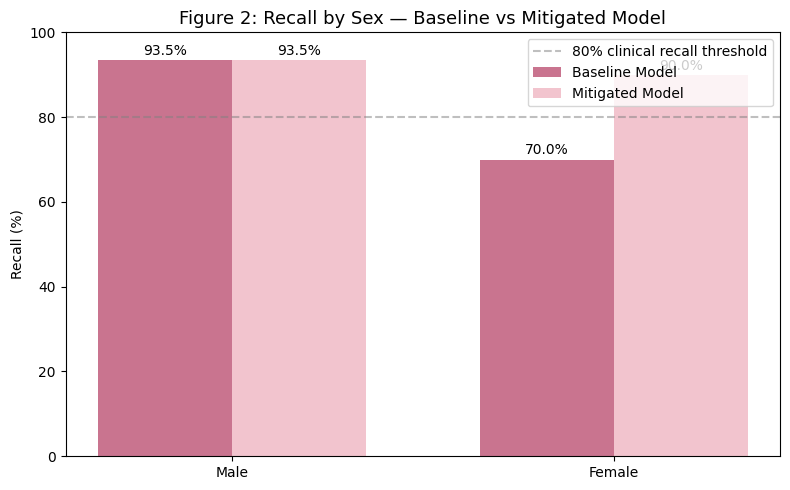

Figure 2 saved — Baseline recall: M=93.5%, F=70.0%
                  Mitigated recall: M=93.5%, F=90.0%


In [19]:

# Compute recall from actual predictions using the shared helper
male_mask = sex_test == 'M'
female_mask = sex_test == 'F'

baseline_recall = [group_metrics(y_test, y_pred, male_mask)[1] * 100,
                   group_metrics(y_test, y_pred, female_mask)[1] * 100]
mitigated_recall = [group_metrics(y_test, y_pred_mitigated, male_mask)[1] * 100,
                    group_metrics(y_test, y_pred_mitigated, female_mask)[1] * 100]

groups = ['Male', 'Female']
x = np.arange(len(groups))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x - width/2, baseline_recall, width,
               label='Baseline Model', color='#c9748f')
bars2 = ax.bar(x + width/2, mitigated_recall, width,
               label='Mitigated Model', color='#f2c4ce')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)

ax.set_title('Figure 2: Recall by Sex — Baseline vs Mitigated Model', fontsize=13)
ax.set_ylabel('Recall (%)')
ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.set_ylim(0, 100)
# axhline must be drawn before legend() or the threshold label is omitted
ax.axhline(y=80, color='grey', linestyle='--', alpha=0.5, label='80% clinical recall threshold')
ax.legend()

plt.tight_layout()
plt.savefig('recall_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Figure 2 saved — Baseline recall: M={baseline_recall[0]:.1f}%, F={baseline_recall[1]:.1f}%")
print(f"                  Mitigated recall: M={mitigated_recall[0]:.1f}%, F={mitigated_recall[1]:.1f}%")


## Section 10: Final Leventhal Assessment Summary

This section presents the final comparison of all six Leventhal procedural justice criteria before and after fairness mitigation. The assessment demonstrates that technical mitigation can reduce some forms of algorithmic disparity while leaving broader dataset and governance limitations unresolved.

Accuracy, consistency, and ethicality meet their respective criteria in both the baseline and mitigated models. Bias suppression improves following the application of Fairlearn's EqualizedOdds mitigation, although the remaining disparity indicates that fairness objectives are not fully achieved. Correctability also improves through the introduction of confidence-based flagging but remains below the predefined threshold because institutional mechanisms such as clinician override and audit processes are outside the scope of this pipeline.

Representativeness remains unchanged, as algorithmic mitigation cannot address limitations in the underlying dataset composition. These remaining challenges highlight the need for complementary data collection and governance interventions alongside technical fairness methods.

In [20]:
print("SECTION 10: FINAL LEVENTHAL ASSESSMENT SUMMARY")
print()


def verdict(passed, improved=False):
    """PASS if the threshold is met, PARTIAL if improved but still short."""
    if passed:
        return "PASS"
    return "PARTIAL" if improved else "FAIL"


# Derived from computed metrics so the table stays consistent with the analysis
correct_base = sum(correctability_checklist.values()) / len(correctability_checklist)
correct_mit = sum(correctability_checklist_updated.values()) / len(correctability_checklist_updated)
ethic = sum(ethicality_checklist.values()) / len(ethicality_checklist)

bias_improved = (abs(dp_diff_mitigated) < abs(dp_diff)) and (abs(eo_diff_mitigated) < abs(eo_diff))

summary = {
    "Accuracy"          : (verdict(auc >= 0.80),
                           verdict(auc_mit >= 0.80),
                           "Quantitative"),
    "Bias Suppression"  : (verdict(abs(dp_diff) <= 0.10 and abs(eo_diff) <= 0.10),
                           verdict(abs(dp_diff_mitigated) <= 0.10 and abs(eo_diff_mitigated) <= 0.10,
                                   improved=bias_improved),
                           "Quantitative"),
    "Representativeness": (verdict(representation_ratio_sex >= 0.80),
                           verdict(representation_ratio_sex >= 0.80),
                           "Quantitative"),
    "Consistency"       : (verdict(instability_rate <= 0.05),
                           verdict(instability_mit <= 0.05,
                                   improved=instability_mit < instability_rate),
                           "Quantitative"),
    "Correctability"    : (verdict(correct_base >= 0.80),
                           verdict(correct_mit >= 0.80, improved=correct_mit > correct_base),
                           "Qualitative"),
    "Ethicality"        : (verdict(ethic >= 0.80),
                           verdict(ethic >= 0.80),
                           "Qualitative"),
}

print(f"{'Rule':<20} {'Baseline':<12} {'Mitigated':<12} {'Method':<15}")
print("-" * 65)
for rule, (baseline, mitigated, method) in summary.items():
    print(f"{rule:<20} {baseline:<12} {mitigated:<12} {method:<15}")

print()
print("Bias Suppression: both metrics improved but neither met the ±0.10 threshold")
print(f"  Demographic parity : {dp_diff:.3f} → {dp_diff_mitigated:.3f}")
print(f"  Equalised odds     : {eo_diff:.3f} → {eo_diff_mitigated:.3f}")

print()
print("Recall by sex (detection rate for patients who do have heart disease):")
print(f"  Male   : {group_metrics(y_test, y_pred, sex_test=='M')[1]:.1%}"
      f" → {group_metrics(y_test, y_pred_mitigated, sex_test=='M')[1]:.1%}")
print(f"  Female : {group_metrics(y_test, y_pred, sex_test=='F')[1]:.1%}"
      f" → {group_metrics(y_test, y_pred_mitigated, sex_test=='F')[1]:.1%}")

print()
print("Key:")
print("  PASS    — criterion met within acceptable threshold")
print("  PARTIAL — criterion still below threshold, but materially improved by mitigation")
print("  FAIL    — criterion not met")
print()
print("Note: Bias suppression improved but remains above the ±0.10 threshold; the small")
print(f"female test sample (n={(sex_test=='F').sum()}) limits the precision of this estimate.")
print("Representativeness and Consistency require data collection solutions.")
print("Correctability requires institutional design. These are addressed as")
print("recommendations in the dissertation.")


SECTION 10: FINAL LEVENTHAL ASSESSMENT SUMMARY

Rule                 Baseline     Mitigated    Method         
-----------------------------------------------------------------
Accuracy             PASS         PASS         Quantitative   
Bias Suppression     FAIL         PARTIAL      Quantitative   
Representativeness   FAIL         FAIL         Quantitative   
Consistency          PASS         PASS         Quantitative   
Correctability       FAIL         PARTIAL      Qualitative    
Ethicality           PASS         PASS         Qualitative    

Bias Suppression: both metrics improved but neither met the ±0.10 threshold
  Demographic parity : 0.457 → 0.380
  Equalised odds     : 0.235 → 0.120

Recall by sex (detection rate for patients who do have heart disease):
  Male   : 93.5% → 93.5%
  Female : 70.0% → 90.0%

Key:
  PASS    — criterion met within acceptable threshold
  PARTIAL — criterion still below threshold, but materially improved by mitigation
  FAIL    — criterion not met

## Section 11: Reproducibility Check

This section consolidates the headline figures reported throughout the notebook into a single output for verification against the values quoted in the dissertation text. All values are read directly from the computed variables rather than being restated manually, so any discrepancy between the notebook and the written report can be identified immediately.

The model feature set and train/test split sizes are also recorded, together with the sex composition of the test set, as the size of the female test sample is a stated limitation of the subgroup fairness estimates.


In [21]:
# Consolidated results for cross-checking against figures quoted in the
# dissertation text. All values are read from the computed variables above.

print("REPRODUCIBILITY CHECK — HEADLINE FIGURES")
print()
print(f"BASELINE  AUROC {auc:.3f}  ACC {overall_accuracy:.3f}")
print(f"  M recall {group_metrics(y_test, y_pred, sex_test=='M')[1]:.3f}"
      f"  F recall {group_metrics(y_test, y_pred, sex_test=='F')[1]:.3f}")
print(f"  DP {dp_diff:.3f}  EO {eo_diff:.3f}")
print(f"MITIGATED AUROC {auc_mit:.3f}  ACC {overall_accuracy_mit:.3f}")
print(f"  M recall {group_metrics(y_test, y_pred_mitigated, sex_test=='M')[1]:.3f}"
      f"  F recall {group_metrics(y_test, y_pred_mitigated, sex_test=='F')[1]:.3f}")
print(f"  DP {dp_diff_mitigated:.3f}  EO {eo_diff_mitigated:.3f}")
print(f"INSTABILITY  baseline {instability_rate:.1%}  mitigated {instability_mit:.1%}")
print(f"FLAGGED {low_conf_count/len(flags)*100:.1f}%")
print(f"REPRESENTATION RATIO {representation_ratio_sex:.2f}")


REPRODUCIBILITY CHECK — HEADLINE FIGURES

BASELINE  AUROC 0.957  ACC 0.891
  M recall 0.935  F recall 0.700
  DP 0.457  EO 0.235
MITIGATED AUROC 0.895  ACC 0.897
  M recall 0.935  F recall 0.900
  DP 0.380  EO 0.120
INSTABILITY  baseline 0.0%  mitigated 1.1%
FLAGGED 10.3%
REPRESENTATION RATIO 0.64


In [22]:
# Feature set and split sizes, recorded for reproducibility
print("Model features:")
for col in X.columns:
    print(f"  {col}")
print()
print(f"Rows: {len(X)} | Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Test composition: {(sex_test=='M').sum()} male, {(sex_test=='F').sum()} female")


Model features:
  Age
  Sex
  RestingBP
  Cholesterol
  FastingBS
  MaxHR
  ExerciseAngina
  Oldpeak
  ChestPainType_ATA
  ChestPainType_NAP
  ChestPainType_TA
  RestingECG_Normal
  RestingECG_ST
  ST_Slope_Flat
  ST_Slope_Up

Rows: 918 | Train: 734 | Test: 184
Test composition: 145 male, 39 female


## References

Citations used within this notebook are listed below. This notebook forms part of the accompanying dissertation, and the reference list below is a subset of the full bibliography presented in that document.

British Heart Foundation (2021a) *UK Factsheet*. London: British Heart Foundation.

British Heart Foundation (2021b) *Heart and Circulatory Disease Statistics 2021*. London: British Heart Foundation.

Dwork, C., Hardt, M., Pitassi, T., Reingold, O. and Zemel, R. (2012) 'Fairness through awareness', *Proceedings of the 3rd Innovations in Theoretical Computer Science Conference (ITCS '12)*. New York: ACM, pp. 214-226.

Equal Employment Opportunity Commission (1978) *Uniform Guidelines on Employee Selection Procedures*, 29 CFR Part 1607. Washington, DC: EEOC.

European Commission High-Level Expert Group on Artificial Intelligence (2020) *The Assessment List for Trustworthy Artificial Intelligence (ALTAI) for Self Assessment*. Brussels: European Commission.

fedesoriano (2021) *Heart Failure Prediction Dataset*. Kaggle. Available at: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction (Accessed: 29 April 2026).

Information Commissioner's Office and The Alan Turing Institute (2020) *Explaining Decisions Made with AI*. Wilmslow: Information Commissioner's Office.

Leventhal, G.S. (1980) 'What should be done with equity theory? New approaches to the study of fairness in social relationships', in Gergen, K.J., Greenberg, M.S. and Willis, R.H. (eds.) *Social Exchange: Advances in Theory and Research*. New York: Plenum Press, pp. 27-55.

Mandrekar, J.N. (2010) 'Receiver operating characteristic curve in diagnostic test assessment', *Journal of Thoracic Oncology*, 5(9), pp. 1315-1316.

Meerwijk, E.L., McElfresh, D.C., Martins, S. and Tamang, S.R. (2024) 'Evaluating accuracy and fairness of clinical decision support algorithms when health care resources are limited', *Journal of Biomedical Informatics*, 156, 104664. doi:10.1016/j.jbi.2024.104664.

Selbst, A.D., Boyd, D., Friedler, S.A., Venkatasubramanian, S. and Vertesi, J. (2019) 'Fairness and abstraction in sociotechnical systems', *Proceedings of the Conference on Fairness, Accountability, and Transparency (FAT* '19)*. New York: ACM, pp. 59-68.